In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import matplotlib.animation as animation
from IPython.display import HTML
from tqdm import tqdm
import os
from matplotlib.colors import Normalize


import warnings
warnings.filterwarnings('ignore')


# Load your pickle file
exp_name = '20241106_3'
pickle_path = '/run/user/1000/gvfs/smb-share:server=bucket.oist.jp,share=bucket/ReiterU/Anouk/basler_data/'+ exp_name+ '/'
output_folder_path = '/run/user/1000/gvfs/smb-share:server=bucket.oist.jp,share=bucket/ReiterU/Anouk/basler_data/'+ exp_name+ '/'
# pickle_path = '/Volumes/ReiterU/Anouk/basler_data/'+ exp_name+ '/'
# output_folder_path = '/Volumes/ReiterU/Anouk/basler_data/'+ exp_name+ '/'


pickle_name_1 = exp_name + '_2_aruco_cleaned_with_speed_col1.pkl'
pickle_name_2 = exp_name + '_2_aruco_cleaned_with_speed_col2.pkl'


col_1, col_2 = 9, 11

In [2]:
def read_pickle_file_with_load(pickle_path, pickle_name):
    """
    Read a DataFrame from a pickle file using `pickle.load`, ensuring the file exists.

    Parameters:
    - pickle_path (str): Path to the folder where the pickle file is located.
    - pickle_name (str): Name of the pickle file (including '.pkl').

    Returns:
    - pd.DataFrame: Loaded DataFrame.
    """
    # Full path to the pickle file
    pickle_full_path = os.path.join(pickle_path, pickle_name)
    
    try:
        print(f"Reading DataFrame from {pickle_full_path} using `pickle.load`...")
        with open(pickle_full_path, 'rb') as f:
            data = pickle.load(f)
        print(f"File '{pickle_name}' read successfully.")
        return data
    except FileNotFoundError:
        print(f"Error: File '{pickle_full_path}' not found.")
    except Exception as e:
        print(f"Error while reading file: {e}")


In [3]:
df_1 = read_pickle_file_with_load(output_folder_path,  pickle_name_1)
df_2 = read_pickle_file_with_load(output_folder_path, pickle_name_2)



Reading DataFrame from /run/user/1000/gvfs/smb-share:server=bucket.oist.jp,share=bucket/ReiterU/Anouk/basler_data/20241106_3/20241106_3_2_aruco_cleaned_with_speed_col1.pkl using `pickle.load`...
File '20241106_3_2_aruco_cleaned_with_speed_col1.pkl' read successfully.
Reading DataFrame from /run/user/1000/gvfs/smb-share:server=bucket.oist.jp,share=bucket/ReiterU/Anouk/basler_data/20241106_3/20241106_3_2_aruco_cleaned_with_speed_col2.pkl using `pickle.load`...
File '20241106_3_2_aruco_cleaned_with_speed_col2.pkl' read successfully.


In [4]:

def calculate_average_distances(df):
    """
    Computes the average distance to all other markers for each ArUco marker in each frame
    and adds it as a new column to the original dataframe.
    
    Parameters:
    - df (pd.DataFrame): DataFrame containing 'Frame_number', 'ARUCO_number', 'X', and 'Y' columns.
    
    Returns:
    - df (pd.DataFrame): Original DataFrame with an added 'avg_distance' column.
    """
    # Initialize an empty list to store distances with a one-to-one correspondence to df's rows
    avg_distances = []

    # Iterate over each frame with a progress bar
    for frame, group in tqdm(df.groupby('Frame_number'), desc="Processing Frames"):
        coords = group[['X', 'Y']].values
        aruco_numbers = group['ARUCO_number'].values
        
        # Calculate pairwise distances
        pairwise_dists = squareform(pdist(coords))
        
        # Calculate average distances for each ArUco marker in this frame
        frame_avg_distances = pairwise_dists.sum(axis=1) / (len(coords) - 1)
        
        # Create a DataFrame to align each avg_distance with the correct ARUCO_number and Frame_number
        frame_distances_df = pd.DataFrame({
            'Frame_number': group['Frame_number'].values,
            'ARUCO_number': aruco_numbers,
            'avg_distance': frame_avg_distances
        })
        
        # Append each frame's data to the main list
        avg_distances.append(frame_distances_df)
    
    # Concatenate all frames into a single DataFrame and merge with the original DataFrame on Frame_number and ARUCO_number
    avg_distances_df = pd.concat(avg_distances, ignore_index=True)
    df = df.merge(avg_distances_df, on=['Frame_number', 'ARUCO_number'], how='left')
    
    return df

# Calculate frame-wise average distances and add to original DataFrames
df_1_with_dist = calculate_average_distances(df_1)
df_2_with_dist = calculate_average_distances(df_2)


Processing Frames: 100%|███████████████████████████████████████████████████████████████████████████████| 86400/86400 [00:26<00:00, 3259.69it/s]


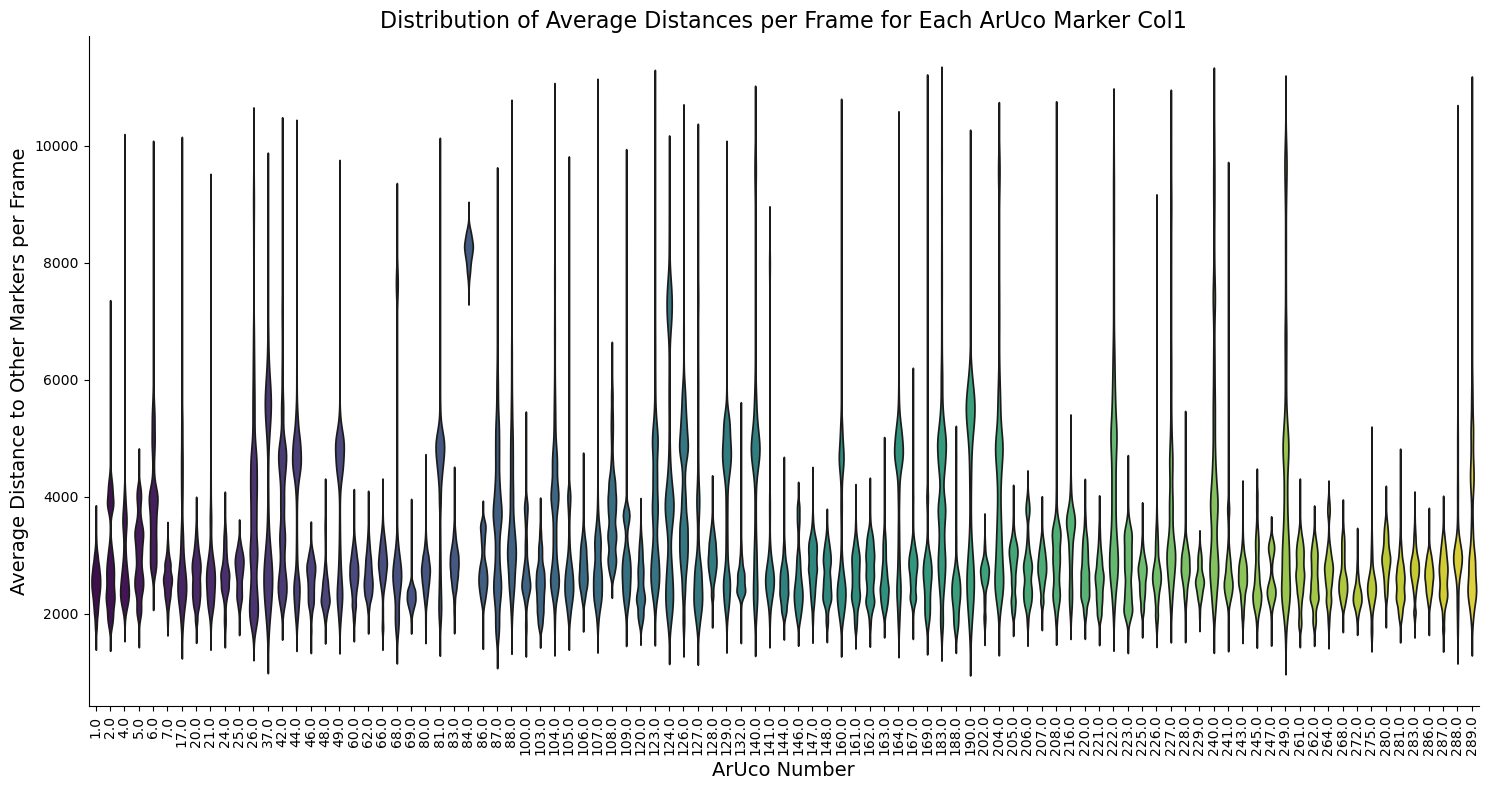

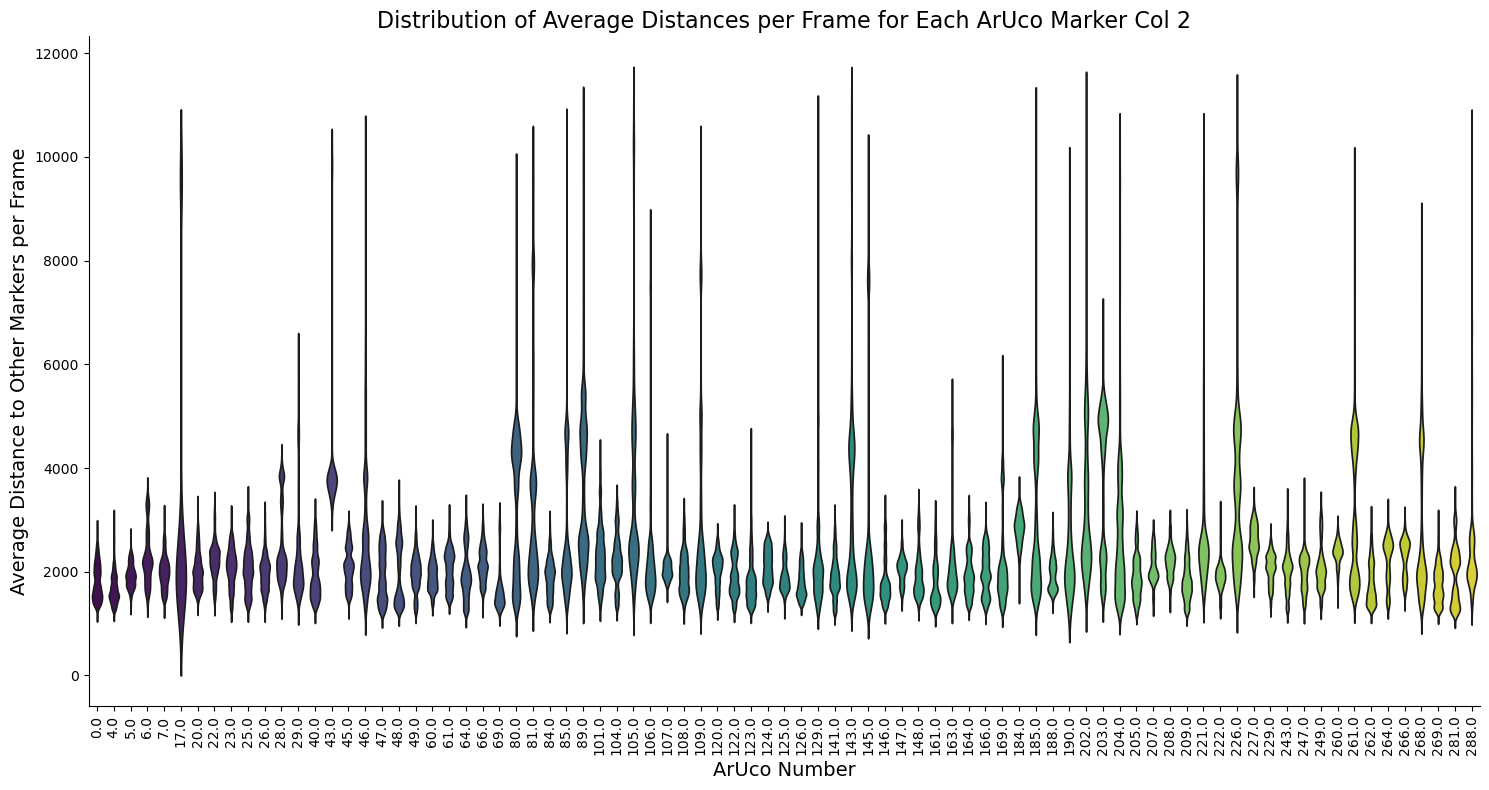

In [5]:

def plot_aruco_distance_distributions(df, title):
    """
    Plots the distribution of average distances for each ArUco marker as a violin plot,
    where each violin shows the distribution of average distances across frames.
    """
    plt.figure(figsize=(15, 8))  # Increased figure size
    
    # Violin plot without inner quartiles
    sns.violinplot(data=df, x='ARUCO_number', y='avg_distance', palette='viridis', width=0.6, inner=None)
    
    # Add a strip plot for individual points
    #sns.stripplot(data=df, x='ARUCO_number', y='avg_distance', color='k', size=2, alpha=0.5, jitter=True)
    
    # Customize the plot aesthetics
    plt.title(title, fontsize=16)
    plt.xlabel('ArUco Number', fontsize=14)
    plt.ylabel('Average Distance to Other Markers per Frame', fontsize=14)
    plt.xticks(rotation=90, fontsize=10)  # Rotate and adjust size of x-tick labels
    
    # Remove the top and right spines for a cleaner look
    sns.despine()
    plt.tight_layout()  # Adjust layout to prevent clipping
    plt.show()

# Example usage:
# plot_aruco_distance_distributions(distance_df, "Distribution of Average Distances per Frame for Each ArUco Marker")

# Plot the distribution of average distances per frame for each ArUco
plot_aruco_distance_distributions(df_1_with_dist, "Distribution of Average Distances per Frame for Each ArUco Marker Col1")
plot_aruco_distance_distributions(df_2_with_dist, "Distribution of Average Distances per Frame for Each ArUco Marker Col 2")


In [ ]:
def check_for_still_aruco(grouped_aruco_df, bad_aruco_numbers):

    """

    Plots ArUco markers with unique colors for those in `bad_aruco_numbers`.

    """
    fig, ax = plt.subplots()
    ax.invert_yaxis()
    unique_colors = plt.cm.tab20(np.linspace(0, 1, len(bad_aruco_numbers)))  # Generate unique colors
    color_map = {aruco: unique_colors[i] for i, aruco in enumerate(bad_aruco_numbers)}  # Map ArUco to colors

    for aruco, data in grouped_aruco_df:
        if aruco in bad_aruco_numbers:
            plt.scatter(data['X'], data['Y'], marker='o', color=color_map[aruco], s=10, zorder=300, label=str(aruco))
        else:
            plt.scatter(data['X'].values, data['Y'].values, marker='o', color='white', alpha=0.5)  

    plt.title('Distribution of Selected ArUco Markers')
    plt.legend(title="ArUco ID")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.show()



potential_bad_arucos_1  = [84 ]
potential_bad_arucos_2  = [ 43]

grouped_by_aruco_1 = df_1_with_dist.groupby('ARUCO_number')
grouped_by_aruco_2 = df_2_with_dist.groupby('ARUCO_number')


check_for_still_aruco(grouped_by_aruco_1, potential_bad_arucos_1)
check_for_still_aruco(grouped_by_aruco_2, potential_bad_arucos_2)


In [6]:
#Remove the false postive
bad_arucos_1 = [84]
bad_arucos_2 = []
df_1_with_dist_cleaned_step3 = df_1_with_dist[~df_1_with_dist['ARUCO_number'].isin(bad_arucos_1 )]
df_2_with_dist_cleaned_step3 = df_2_with_dist[~df_2_with_dist['ARUCO_number'].isin(bad_arucos_2 )]

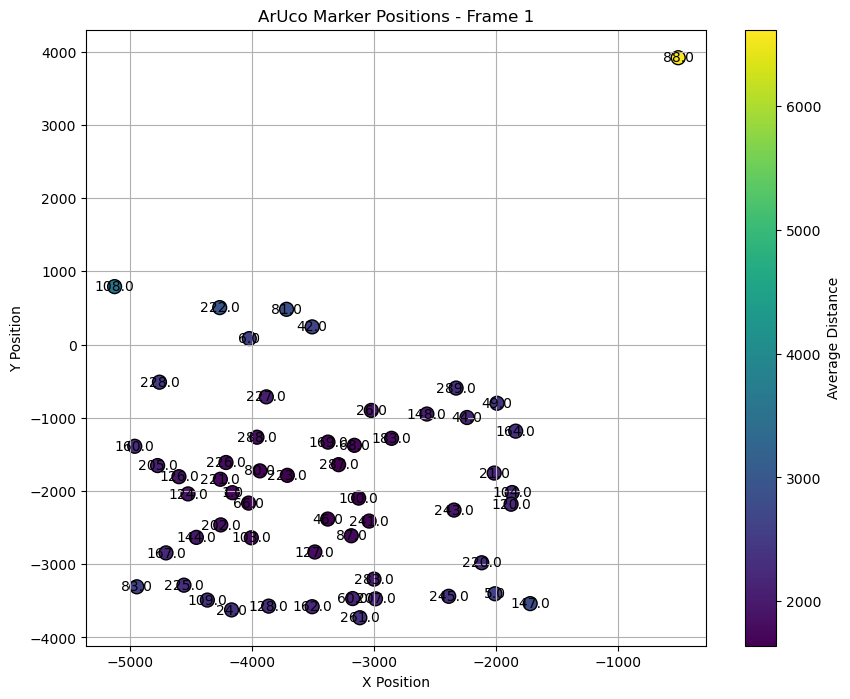

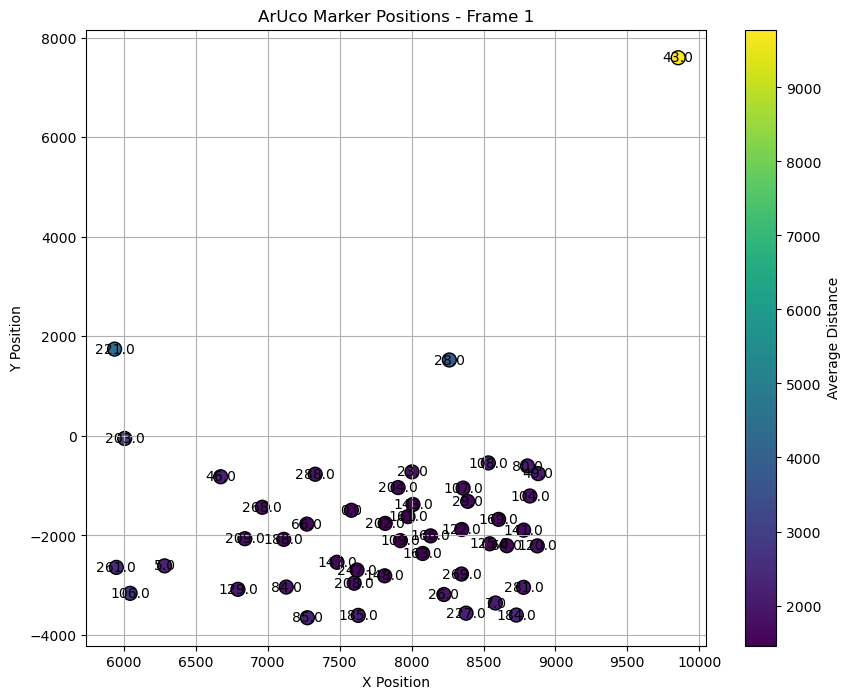

In [7]:

def plot_arucos_with_avg_distance(df, frame_number):
    """
    Plots ArUco marker positions for a specific frame with color indicating average distance.
    
    Parameters:
    - df (pd.DataFrame): DataFrame with 'X', 'Y', 'avg_distance', 'ARUCO_number', 'Frame_number'.
    - frame_number (int): The specific frame to plot.
    """
    # Filter data for the specified frame
    frame_df = df[df['Frame_number'] == frame_number]
    
    # Create a normalization based on 'avg_distance' values
    norm = Normalize(vmin=frame_df['avg_distance'].min(), vmax=frame_df['avg_distance'].max())
    
    # Plot the ArUco markers
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        frame_df['X'], frame_df['Y'], c=frame_df['avg_distance'], s=100, cmap='viridis', norm=norm, edgecolor='k'
    )
    
    # Create a color bar with the same normalization
    cbar = plt.colorbar(scatter, label='Average Distance')  # Directly link the color bar to the scatter plot
    
    # Annotate ArUco IDs
    for _, row in frame_df.iterrows():
        plt.text(row['X'], row['Y'], str(row['ARUCO_number']), fontsize=10, ha='center', va='center')
    
    # Add labels and title
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.title(f"ArUco Marker Positions - Frame {frame_number}")
    plt.grid()
    plt.show()

# Example usage for a specific frame
plot_arucos_with_avg_distance(df_1_with_dist_cleaned_step3, frame_number=1)
plot_arucos_with_avg_distance(df_2_with_dist_cleaned_step3, frame_number=1)



In [8]:
#Save the active_arucos (uncleaned) 
def convert_to_pickle(folder_path, pickle_name, df_to_convert): 
    #Create a new folder with the combined files in the desired directory 
    folder_name = folder_path.split('/')[-2]
    if not os.path.exists(folder_path):
        # If the folder does not exist, create it
        os.makedirs(folder_path)
        print(f"Folder '{folder_name}' created in '{folder_path}'.")
    else:
        print(f"Folder '{folder_name}' already exists in '{folder_path}'.")

    df_to_convert.to_pickle(folder_path +  pickle_name )
    
    return

convert_to_pickle(output_folder_path, exp_name + '_3_aruco_cleaned_with_avg_dist_col1.pkl', df_1_with_dist_cleaned_step3)
convert_to_pickle(output_folder_path, exp_name + '_3_aruco_cleaned_with_avg_dist_col2.pkl', df_2_with_dist_cleaned_step3)


Folder '20241106_3' already exists in '/run/user/1000/gvfs/smb-share:server=bucket.oist.jp,share=bucket/ReiterU/Anouk/basler_data/20241106_3/'.
Folder '20241106_3' already exists in '/run/user/1000/gvfs/smb-share:server=bucket.oist.jp,share=bucket/ReiterU/Anouk/basler_data/20241106_3/'.
